<a href="https://colab.research.google.com/github/SHASHANK8412/DL-Lab/blob/main/DL_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.



Training with learning rate = 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Loss (MSE): 36179.01

Training with learning rate = 0.001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Loss (MSE): 516.33

Training with learning rate = 0.01
Loss (MSE): 3152.32

Training with learning rate = 0.1
Loss (MSE): 25.99

Training with learning rate = 0.5
Loss (MSE): 161.13


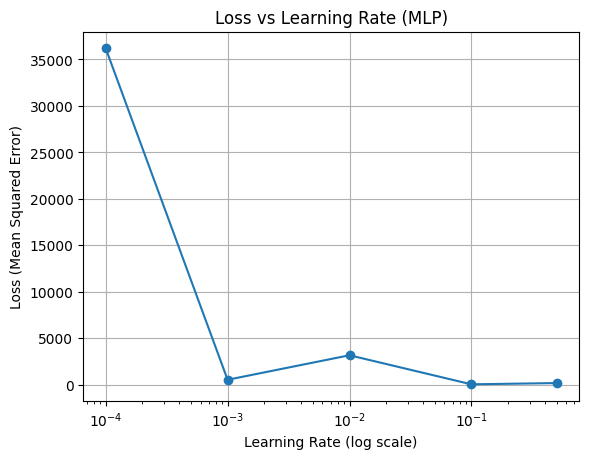


Final Results:
Learning Rate: 0.0001 --> Loss: 36179.01
Learning Rate: 0.001 --> Loss: 516.33
Learning Rate: 0.01 --> Loss: 3152.32
Learning Rate: 0.1 --> Loss: 25.99
Learning Rate: 0.5 --> Loss: 161.13


In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# ==============================
# LOAD DATASET
# ==============================
df = pd.read_csv("IPL2025Batters.csv")

# ==============================
# PREPROCESSING
# ==============================
# Keep only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Features (X) and Target (y)
X = df_numeric.drop("Runs", axis=1)
y = df_numeric["Runs"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# MLP TRAINING WITH DIFFERENT LEARNING RATES
# ==============================
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]

losses = []

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")

    model = MLPRegressor(
        hidden_layer_sizes=(50, 30),
        activation='relu',
        solver='adam',
        learning_rate_init=lr,
        max_iter=1000,
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Calculate Loss (MSE)
    loss = mean_squared_error(y_test, y_pred)
    losses.append(loss)

    print(f"Loss (MSE): {loss:.2f}")

# ==============================
# PLOT GRAPH
# ==============================
plt.figure()
plt.plot(learning_rates, losses, marker='o')

plt.xscale('log')   # Log scale for better visualization
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("Loss vs Learning Rate (MLP)")
plt.grid()

plt.show()

# ==============================
# PRINT FINAL RESULTS
# ==============================
print("\nFinal Results:")
for lr, loss in zip(learning_rates, losses):
    print(f"Learning Rate: {lr} --> Loss: {loss:.2f}")

### Perceptron Implementation on IPL2025 Dataset

Since `sklearn.linear_model.Perceptron` is a binary classifier, we first need to convert our continuous target variable ('Runs') into a binary one. We will create a new column 'high_scorer' which will be 1 if a player's runs are above the median runs, and 0 otherwise. We will then explore the impact of `eta0` (learning rate) and `max_iter` on the Perceptron's accuracy.

Exploring Perceptron with different learning rates (eta0):

Training Perceptron with eta0 = 0.0001
Accuracy with eta0=0.0001: 0.9688

Training Perceptron with eta0 = 0.001
Accuracy with eta0=0.001: 0.9688

Training Perceptron with eta0 = 0.01
Accuracy with eta0=0.01: 0.9688

Training Perceptron with eta0 = 0.1
Accuracy with eta0=0.1: 0.9688

Training Perceptron with eta0 = 1.0
Accuracy with eta0=1.0: 0.9688

Exploring Perceptron with different max_iter (using eta0=0.1):

Training Perceptron with max_iter = 100
Accuracy with max_iter=100: 0.9688

Training Perceptron with max_iter = 500
Accuracy with max_iter=500: 0.9688

Training Perceptron with max_iter = 1000
Accuracy with max_iter=1000: 0.9688

Training Perceptron with max_iter = 2000
Accuracy with max_iter=2000: 0.9688


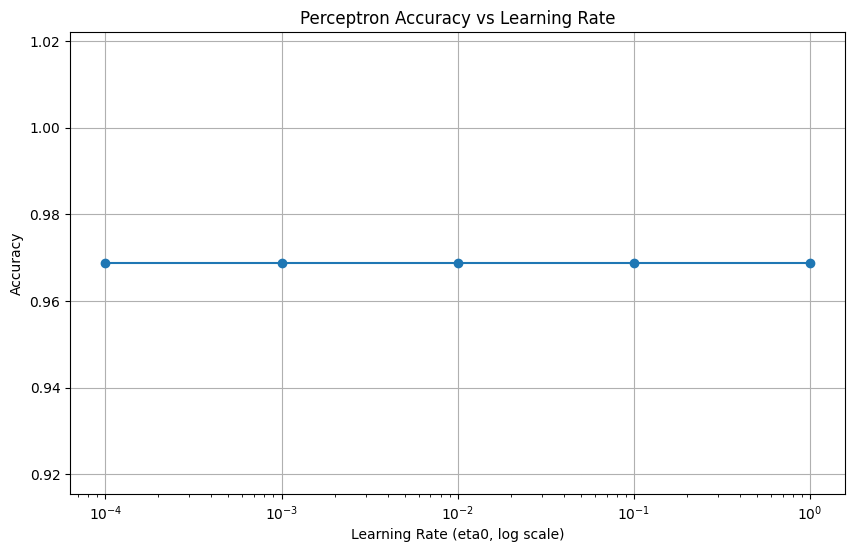


Perceptron Final Results (Learning Rate Exploration):
Learning Rate: 0.0001 --> Accuracy: 0.9688
Learning Rate: 0.001 --> Accuracy: 0.9688
Learning Rate: 0.01 --> Accuracy: 0.9688
Learning Rate: 0.1 --> Accuracy: 0.9688
Learning Rate: 1.0 --> Accuracy: 0.9688


In [3]:
# ==============================
# PERCEPTRON IMPLEMENTATION
# ==============================

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Create a binary target for Perceptron
median_runs = df_numeric["Runs"].median()
df_numeric["high_scorer"] = (df_numeric["Runs"] > median_runs).astype(int)

# Features (X) and new Target (y_clf) for Perceptron
X_clf = df_numeric.drop(["Runs", "high_scorer"], axis=1)
y_clf = df_numeric["high_scorer"]

# Train-Test Split for Perceptron
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Feature Scaling for Perceptron
scaler_clf = StandardScaler()
X_train_clf = scaler_clf.fit_transform(X_train_clf)
X_test_clf = scaler_clf.transform(X_test_clf)

perceptron_learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
perceptron_accuracies = []

print("Exploring Perceptron with different learning rates (eta0):")
for lr in perceptron_learning_rates:
    print(f"\nTraining Perceptron with eta0 = {lr}")
    perceptron_model = Perceptron(eta0=lr, random_state=42, max_iter=1000, tol=1e-3)
    perceptron_model.fit(X_train_clf, y_train_clf)
    y_pred_clf = perceptron_model.predict(X_test_clf)
    accuracy = accuracy_score(y_test_clf, y_pred_clf)
    perceptron_accuracies.append(accuracy)
    print(f"Accuracy with eta0={lr}: {accuracy:.4f}")

# Explore max_iter for a chosen learning rate
perceptron_max_iter = [100, 500, 1000, 2000]
print("\nExploring Perceptron with different max_iter (using eta0=0.1):")
for mi in perceptron_max_iter:
    print(f"\nTraining Perceptron with max_iter = {mi}")
    perceptron_model = Perceptron(eta0=0.1, random_state=42, max_iter=mi, tol=1e-3)
    perceptron_model.fit(X_train_clf, y_train_clf)
    y_pred_clf = perceptron_model.predict(X_test_clf)
    accuracy = accuracy_score(y_test_clf, y_pred_clf)
    print(f"Accuracy with max_iter={mi}: {accuracy:.4f}")

# Plotting results for Perceptron learning rates
plt.figure(figsize=(10, 6))
plt.plot(perceptron_learning_rates, perceptron_accuracies, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate (eta0, log scale)")
plt.ylabel("Accuracy")
plt.title("Perceptron Accuracy vs Learning Rate")
plt.grid()
plt.show()

print("\nPerceptron Final Results (Learning Rate Exploration):")
for lr, acc in zip(perceptron_learning_rates, perceptron_accuracies):
    print(f"Learning Rate: {lr} --> Accuracy: {acc:.4f}")

### MLP Implementation with Stochastic Gradient Descent (SGD) Solver

Here, we implement the MLP Regressor using the `sgd` solver to demonstrate a Gradient Descent algorithm, as requested. We will explore different learning rates and visualize their respective loss curves to analyze the convergence behavior over iterations.

Implementing MLPRegressor with 'sgd' solver and analyzing convergence.

Training MLPRegressor with SGD solver, learning rate = 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Loss (MSE) with SGD: 33.67

Training MLPRegressor with SGD solver, learning rate = 0.001
Loss (MSE) with SGD: 35450.45

Training MLPRegressor with SGD solver, learning rate = 0.01
Loss (MSE) with SGD: 37073804412882110480646144.00

Training MLPRegressor with SGD solver, learning rate = 0.1
Loss (MSE) with SGD: 3231080688753166156703182935897931776.00


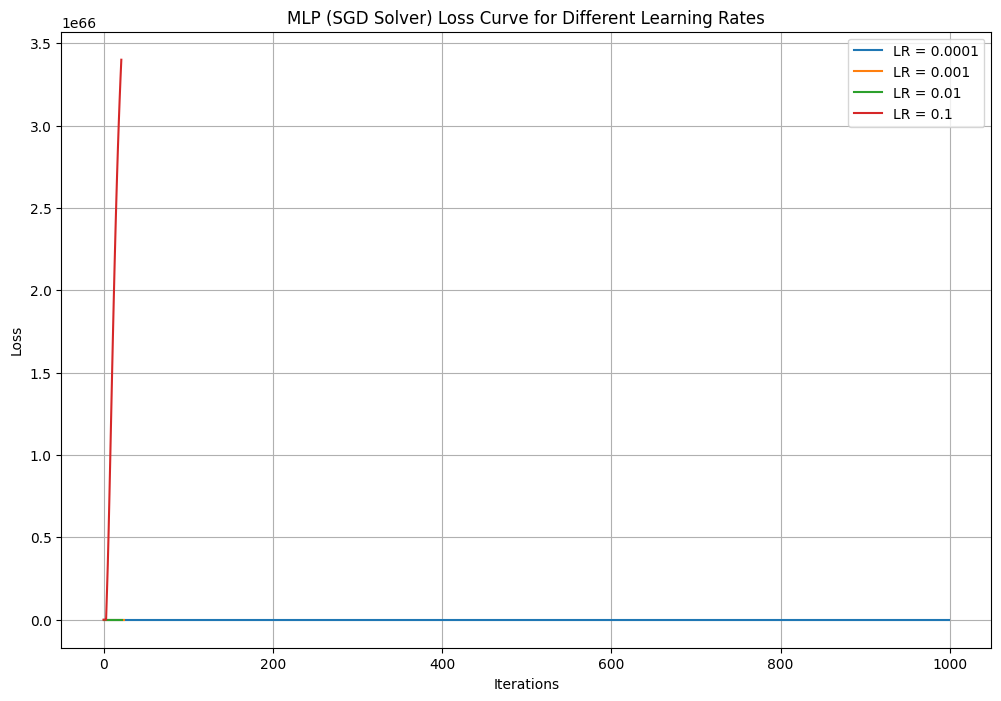

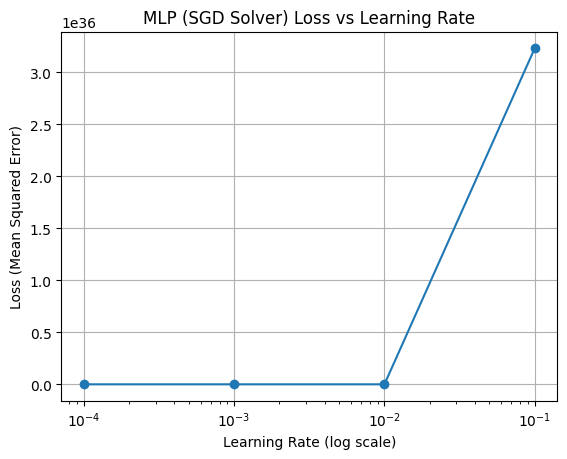


MLP (SGD Solver) Final Results:
Learning Rate: 0.0001 --> Loss: 33.67
Learning Rate: 0.001 --> Loss: 35450.45
Learning Rate: 0.01 --> Loss: 37073804412882110480646144.00
Learning Rate: 0.1 --> Loss: 3231080688753166156703182935897931776.00


In [4]:
# ==============================
# MLP TRAINING WITH SGD SOLVER AND CONVERGENCE ANALYSIS
# ==============================

print("Implementing MLPRegressor with 'sgd' solver and analyzing convergence.")

mlp_sgd_learning_rates = [0.0001, 0.001, 0.01, 0.1] # Selected learning rates for SGD
sgd_losses = []
sgd_loss_curves = []

for lr in mlp_sgd_learning_rates:
    print(f"\nTraining MLPRegressor with SGD solver, learning rate = {lr}")

    # X_train, y_train, X_test, y_test are available from previous preprocessing steps.

    model_sgd = MLPRegressor(
        hidden_layer_sizes=(50, 30),
        activation='relu',
        solver='sgd', # Changed to SGD
        learning_rate_init=lr,
        max_iter=1000,
        random_state=42,
        n_iter_no_change=20, # Number of iterations with no improvement to wait before early stopping.
        tol=1e-4 # Tolerance for the optimization.
    )

    # Train model
    model_sgd.fit(X_train, y_train)

    # Store loss curve
    sgd_loss_curves.append(model_sgd.loss_curve_)

    # Predictions
    y_pred_sgd = model_sgd.predict(X_test)

    # Calculate Loss (MSE)
    loss_sgd = mean_squared_error(y_test, y_pred_sgd)
    sgd_losses.append(loss_sgd)

    print(f"Loss (MSE) with SGD: {loss_sgd:.2f}")

# ==============================
# PLOT CONVERGENCE GRAPHS FOR SGD
# ==============================
plt.figure(figsize=(12, 8))
for i, lr in enumerate(mlp_sgd_learning_rates):
    plt.plot(sgd_loss_curves[i], label=f'LR = {lr}')

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP (SGD Solver) Loss Curve for Different Learning Rates")
plt.legend()
plt.grid()
plt.show()

# ==============================
# PLOT FINAL LOSS VS LEARNING RATE FOR SGD
# ==============================
plt.figure()
plt.plot(mlp_sgd_learning_rates, sgd_losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("MLP (SGD Solver) Loss vs Learning Rate")
plt.grid()
plt.show()

print("\nMLP (SGD Solver) Final Results:")
for lr, loss in zip(mlp_sgd_learning_rates, sgd_losses):
    print(f"Learning Rate: {lr} --> Loss: {loss:.2f}")